# Perceptrón de Hinton
### Descripción General del Práctico
En este práctico, exploraremos la implementación y el entrenamiento de un modelo Perdeptrón de Hinton para generación de imágenes. Usaremos los datasets [MNIST](https://es.wikipedia.org/wiki/Base_de_datos_MNIST) y [FashionMNIST](https://en.wikipedia.org/wiki/Fashion_MNIST).

### Objetivo del Práctico
El objetivo de este práctico es endender cómo se implementa y entrena el Perceptrón presentado por Hinton para generación de imágenes.

### Imports

In [1]:
# !pip install torchvision

In [2]:
#!pip install torch

In [3]:
import time
import math
import torch
import random
import matplotlib.pyplot as plt
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data.dataloader import DataLoader
from tqdm import tqdm

### Seteo de Device

Seteamos sobre que dispositivo vamos a estar corriendo el entrenamiento e inferencia.

In [4]:
DEVICE = torch.device(
    'cuda:0' if torch.cuda.is_available() else 
    'mps' if torch.backends.mps.is_available() else 
    'cpu'
)
print(DEVICE)

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

mps


### Transformaciones:

Creamos la transformación para binarizar nuestro dataset. Esto va a hacer que pasemos de $[0, 256]$ a $\{0, 1\}$. A su vez agregamos la transformación trabajar con tensores.

In [5]:
class BinarizedTransform:
    def __call__(self, img):
        return (img > .5).float()
    
img_transforms = transforms.Compose([transforms.ToTensor(), BinarizedTransform()])
img_shape = (28,28)
img_size = 28*28*1
num_classes = 10

### Dataset

Vamos a estar trabajando con el dataset de [MNIST](https://es.wikipedia.org/wiki/Base_de_datos_MNIST) que nos brinda imágenes de 28*28 de dígitos escritos a mano.

Para la generación vamos a estar trabajando únicamente con un solo dígito. Vamos a setearlo en este momento y continuamos trabajando con este.

In [6]:
labels_used = [1]

### Carga de datos y creación de Dataloader.

In [7]:
BATCH_SIZE = 32

download_dataset = True # If you already have the dataset you could use False

train_data = datasets.MNIST(root='mnist/', train=True, transform=img_transforms, download=download_dataset)
train_data = [(image, label) for image, label in train_data if labels_used and label in labels_used]

train_dataloader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True
)


### Exploración del Dataset

In [8]:
def show_images(images, title="MNIST Images"):
    n = len(images)
    rows = math.floor(math.sqrt(n))
    columns = math.ceil(n / rows)

    fig, axs = plt.subplots(rows, columns)
    fig.suptitle(title, fontsize=14, y=.95)

    for i in range(rows):
        for j in range(columns):
            index = i*columns + j
            if index < n:
                axs[i,j].imshow(images[index], cmap='gray')
            axs[i,j].axis('off')

    plt.show()

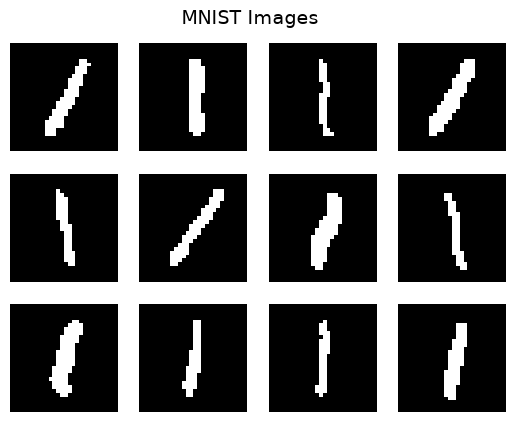

In [9]:
images = []
for _ in range(12):
    image, label = train_data[random.randrange(len(train_data))]
    images.append(image.reshape(img_shape))
show_images(images)

### Definicion de Hinton Perceptron

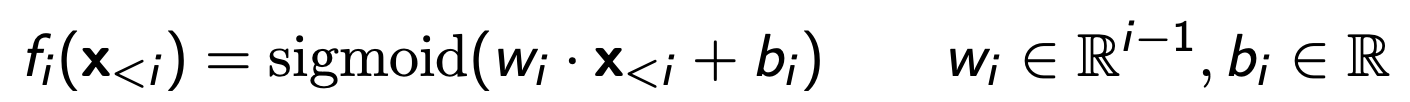

Para replicar esto usaremos una máscara que deje a todos los pesos que "ven el futuro" no afecten la predicción.
Revisar [torch.tril](https://docs.pytorch.org/docs/stable/generated/torch.tril.html). No se olviden de la diagonal!

In [10]:
ones = torch.ones((3,3))

masked_ones = torch.tril(ones, diagonal=-1)
print(masked_ones.T)
print(torch.matmul(ones, masked_ones.T))

tensor([[0., 1., 1.],
        [0., 0., 1.],
        [0., 0., 0.]])
tensor([[0., 1., 2.],
        [0., 1., 2.],
        [0., 1., 2.]])


In [11]:
torch.tril(ones, diagonal=-1).T

tensor([[0., 1., 1.],
        [0., 0., 1.],
        [0., 0., 0.]])

¿Qué resultado debería dara la multiplicación de ones . masked_ones.T?

Dado que se le aplica torch.tril(ones, diagonal=-1), los valores desde la diagonal principal y una diagonal por encima quedan en 0, como resultado de aplicar la multiplicación se genera otro tensor de 3x3:

tensor([[0., 1., 2.],
        [0., 1., 2.],
        [0., 1., 2.]]).

Recomendamos usar [nn.Parameter](https://docs.pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html) para la definición de los pesos y del bias.

In [12]:
class HintonPerceptron(nn.Module):
    def __init__(
        self,
        input_size: int,
        img_shape: tuple[int, int]
    ):
        super(HintonPerceptron, self).__init__()
        self.img_shape = img_shape
        self.img_size = torch.prod(torch.tensor(img_shape)).item()

        # Inicializamos pesos W
        self.w = nn.Parameter(torch.randn(self.img_size, input_size) * 0.01) # esto es para comenzar sigmoide con pesos chicos, sino Loss inicial puede ser enorme y diría "encendido siempre"

        # Guardamos la máscara        
        self.register_buffer('mask'
                            ,torch.tril(torch.ones(self.img_size, input_size), diagonal=-1)
                            )

        # Inicializamos bias b
        self.bias = nn.Parameter(torch.zeros(self.img_size))
        
    def forward(
        self,
        x: torch.Tensor
    ):
        # Aplicamos la máscara a w para no usar pesos futuros
        w_masked = self.w * self.mask

        # Multiplicamos x . w^T (w transpuesta)
        x_w = torch.matmul(x, w_masked.T)

        # Sumamos el bias
        logits = x_w + self.bias
        
        # Aplicamos la función de activación y retornamos
        return torch.sigmoid(logits)
    
    def generate_x(
        self,
        num_images: int
    ):
        # Usamos torch.no_grad() porque no necesitamos gradientes para generar imágenes
        with torch.no_grad():
            # Generamos imágenes de tamaño num_images x img_size
            x = torch.zeros(num_images, self.img_size, device=self.w.device)
            # Para cada píxel
            for i in range(self.img_size):
                # Obtenemos la salida de la red basada en los pixeles generadas hasta ahora
                probs = self.forward(x)
                # Muestreamos una distribución Bernoulli para obtener el valor del píxel
                x[:, i] = torch.bernoulli(probs[:, i])
            # Retornamos las imágenes generadas (en formato de imagen, precisamos redimensionar)
            return x.reshape(num_images, *self.img_shape)

### Creación del modelo y seteo de Hyper-parámetros
En esta sección del código, se crea el modelo.

Y se eligen arbitrariamente los siguientes hyper-parámetros:
- learning rate (lr)
- cantidad de épocas (epochs)
- optimizador (optim)

In [13]:
lr = 1e-3
epochs = 100
criterion = nn.BCELoss() # función de pérdida

model = HintonPerceptron(
    input_size=img_size,
    img_shape=img_shape
).to(DEVICE)

optim = torch.optim.Adam(model.parameters(), lr=lr)

¿Por qué eligió usar esa función de pérdida?

Se usa la Binary Cross Entropy como función de pérdida porque se asume que los píxeles siguen una distribución Bernoulli que toma valores entre 0 y 1. 

### Proceso de entrenamiento del modelo
En esta celda, se define el entrenamiento del modelo utilizando un conjunto de datos de entrenamiento.

El código optimiza los parámetros del modelo minimizando la función de pérdida previamente definida a través de un optimizador.

In [14]:
def train_model(
    model: nn.Module,
    criterion: nn.Module,
    n_epochs: int,
    train_loader: DataLoader,
    optim: torch.optim.Optimizer,
    print_epoch: int = 1
):
    for epoch in tqdm(range(n_epochs)):
        start_time = time.time()
        learning_error = 0
        for img, _ in train_loader:
            # Aplanamos la imagen y la movemos al dispositivo correspondiente
            x = img.view(img.size(0), -1).to(DEVICE) # (B, 1, 28, 28) -> (B, 784)
    
            # Reseteamos los gradientes
            optim.zero_grad()

            # Hacemos la predicción
            preds = model(x)    # (B, 784): p(x_i = 1 | x_<i)

            # Calculamos la loss
            loss = criterion(preds, x)

            # Hacemos backprop
            loss.backward()

            # Optimizamos
            optim.step()

            learning_error += loss.item() # Acumulamos la pérdida

        if epoch%print_epoch == 0:
            imgs = model.generate_x(12).cpu()
            show_images(imgs, f"Generated images on epoch {epoch+1}")
            print(f"Epoch: {epoch+1} - duration {time.time()-start_time}s- error: {learning_error/len(train_loader)}")

    return model

¿Por qué no usamos los valores de `y` que tiene el dataset? ¿No nos afecta esto al calcular la loss?

Porque esto es un modelo autoregresivo donde la predicción se usa los valores anteriores para predecir el siguiente, por eso la loss se calcula `x_^ - x`

### Entrenamos el modelo!

Se puede observavr que en la epoch 1 las imagenes generadas los primeros píxeles estaban encendidos, además tiene bastante ruido a pesar de que las imagénes generadas parecen tener un palo en el medio. En la epoch 20 ya disminuyen la cantidad de primeros píxeles prendidos de forma errónea.

  0%|          | 0/100 [00:00<?, ?it/s]

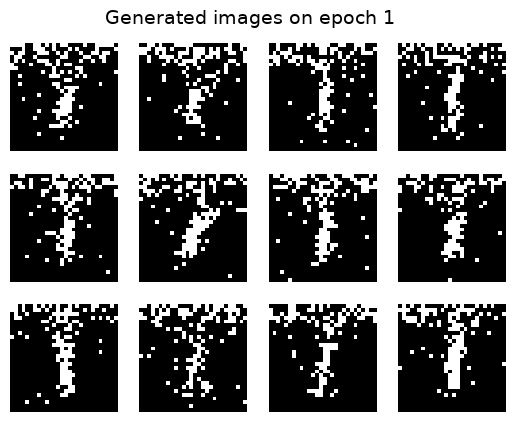

  1%|          | 1/100 [00:00<01:09,  1.43it/s]

Epoch: 1 - duration 0.6986768245697021s- error: 0.3319385250880255


 20%|██        | 20/100 [00:09<00:41,  1.94it/s]

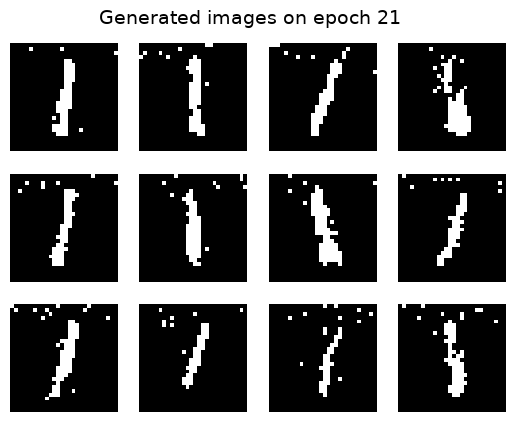

 21%|██        | 21/100 [00:10<00:47,  1.67it/s]

Epoch: 21 - duration 0.794806957244873s- error: 0.051333326493253076


 40%|████      | 40/100 [00:16<00:17,  3.39it/s]

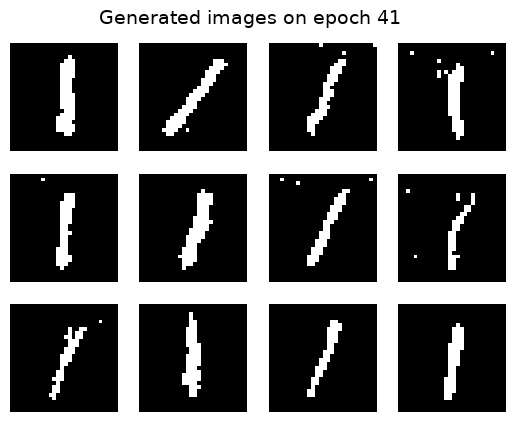

 41%|████      | 41/100 [00:16<00:20,  2.90it/s]

Epoch: 41 - duration 0.46272921562194824s- error: 0.03813566926036966


 60%|██████    | 60/100 [00:24<00:20,  1.96it/s]

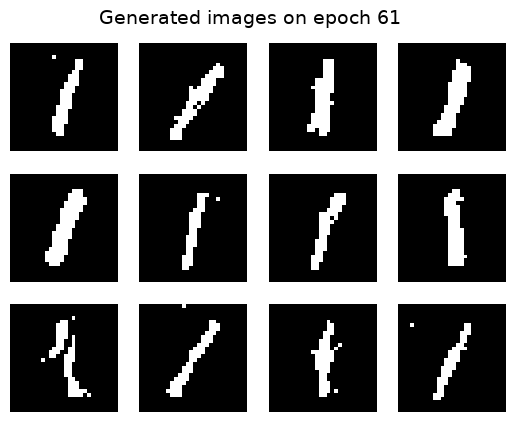

 61%|██████    | 61/100 [00:25<00:22,  1.73it/s]

Epoch: 61 - duration 0.7316849231719971s- error: 0.03502551213754297


 80%|████████  | 80/100 [00:35<00:10,  1.88it/s]

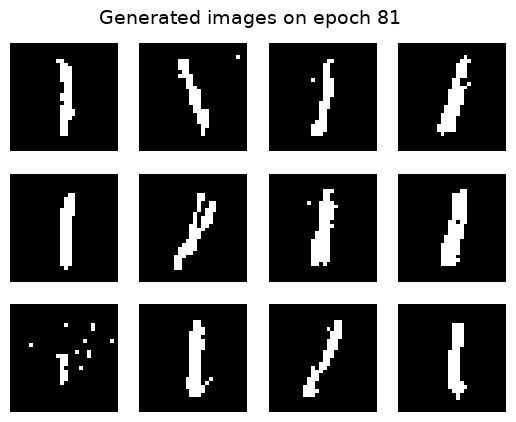

 81%|████████  | 81/100 [00:35<00:11,  1.68it/s]

Epoch: 81 - duration 0.738105058670044s- error: 0.033783326490442335


100%|██████████| 100/100 [00:41<00:00,  2.42it/s]


In [15]:
trained_model = train_model(
    model=model,
    criterion=criterion,
    n_epochs=int(epochs),
    train_loader=train_dataloader,
    optim=optim,
    print_epoch=20
)

### Probamos el modelo generando imagenes

No parece ser un modelo bueno, si bien en las doce imagenes generadas once se pueden identificar que es el número 1 pero hay cuatro que tienen un píxel prendido. A su vez, se puede observar que la imagen de la primera fila y segunda columna no está cerca de parecerse al número que el modelo vio en el entrenamiento. 

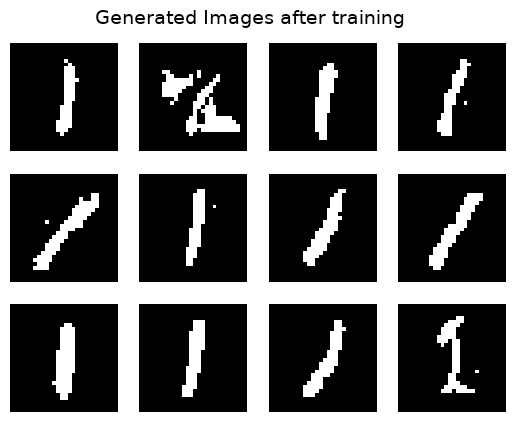

In [16]:
imgs = model.generate_x(12).cpu()
show_images(imgs, "Generated Images after training")

## Ejercicios:
1) Complete el código del perceptrón de Hinton.
2) Entrene el modelo utilizando 1 dígito.
3) Entrene el modelo utilizando al menos 3 dígitos.

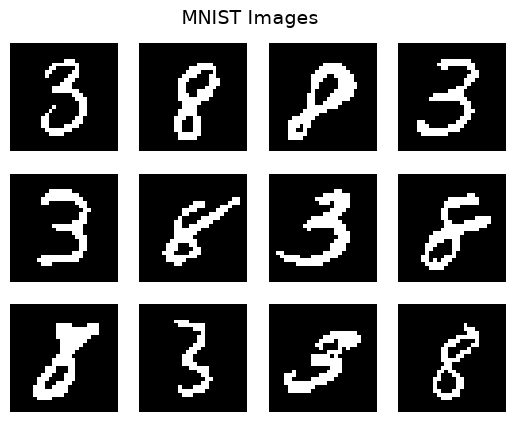

In [17]:
labels_used = [3, 8]

download_dataset = True # If you already have the dataset you could use False

train_data = datasets.MNIST(root='mnist/', train=True, transform=img_transforms, download=download_dataset)

train_data = [(image, label) for image, label in train_data if labels_used and label in labels_used]

train_dataloader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True
)

images = []
for _ in range(12):
    image, label = train_data[random.randrange(len(train_data))]
    images.append(image.reshape(img_shape))
show_images(images)

  0%|          | 0/100 [00:00<?, ?it/s]

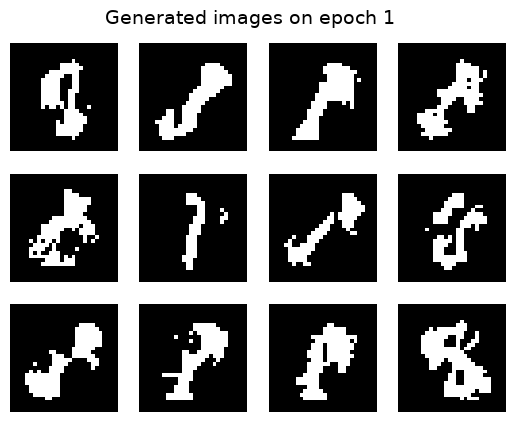

  1%|          | 1/100 [00:01<01:58,  1.19s/it]

Epoch: 1 - duration 1.1926887035369873s- error: 0.34224996519088746


 20%|██        | 20/100 [00:19<01:18,  1.02it/s]

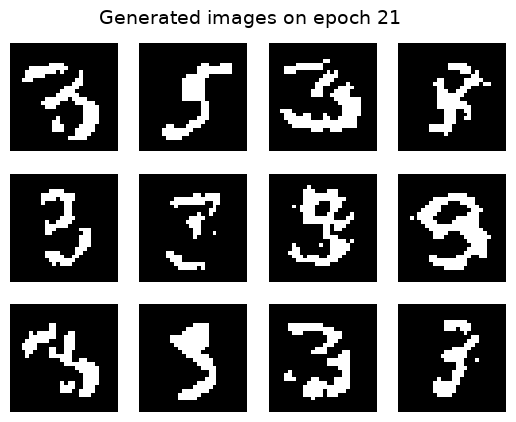

 21%|██        | 21/100 [00:20<01:21,  1.04s/it]

Epoch: 21 - duration 1.162447214126587s- error: 0.1059452447493871


 40%|████      | 40/100 [00:34<00:56,  1.05it/s]

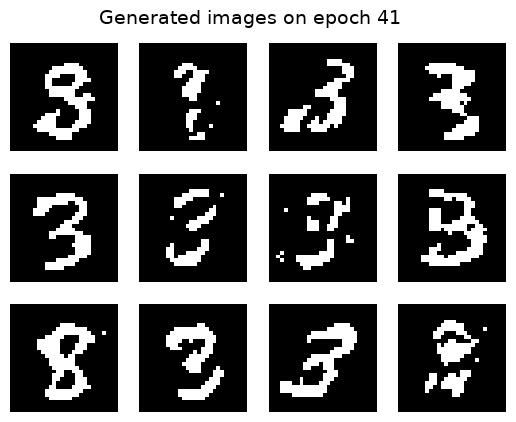

 41%|████      | 41/100 [00:35<00:59,  1.01s/it]

Epoch: 41 - duration 1.1459062099456787s- error: 0.09836006299654643


 60%|██████    | 60/100 [00:53<00:39,  1.01it/s]

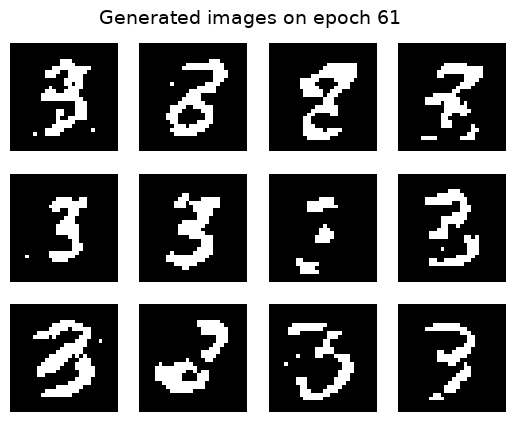

 61%|██████    | 61/100 [00:54<00:38,  1.00it/s]

Epoch: 61 - duration 1.0259549617767334s- error: 0.09616118053595225


 80%|████████  | 80/100 [01:12<00:19,  1.03it/s]

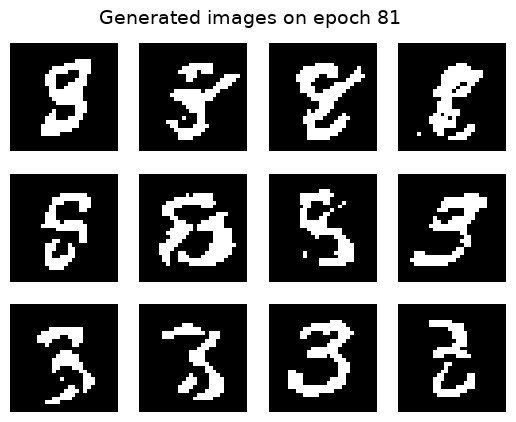

 81%|████████  | 81/100 [01:13<00:18,  1.03it/s]

Epoch: 81 - duration 0.9636929035186768s- error: 0.09521612719694773


100%|██████████| 100/100 [01:29<00:00,  1.12it/s]


In [18]:
trained_model = train_model(
    model=model,
    criterion=criterion,
    n_epochs=int(epochs),
    train_loader=train_dataloader,
    optim=optim,
    print_epoch=20
)

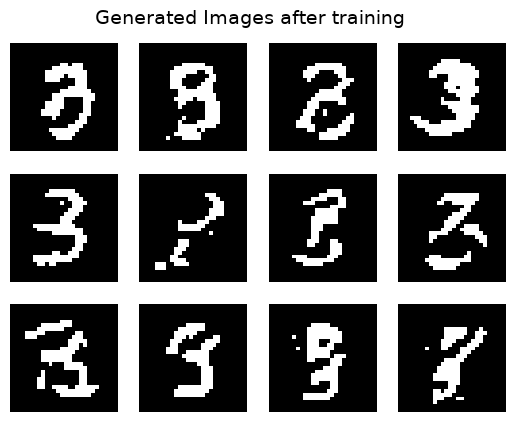

In [19]:
imgs = model.generate_x(12).cpu()
show_images(imgs, "Generated Images after training")

4) Compare resultados. ¿Qué diferencias observas?



5) Entrene el modelo con el dataset de [FashionMNIST](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).

In [25]:
fmnist_train_data = datasets.FashionMNIST(
    root='fmnist/', download=True, train=True, transform=img_transforms
)

In [26]:
fminst_train_dataloader = DataLoader(
    fmnist_train_data, batch_size=BATCH_SIZE, shuffle=True
)

In [34]:
class_names = fmnist_train_data.classes
nclasses = len(class_names)

print(f"Clases: {class_names}")

Clases: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [ ]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

In [38]:
def show_fashion_images(dataset, classes, num_images=12):
    if isinstance(classes, str):
        classes = [classes]

    name_to_label = {name: i for i, name in enumerate(class_names)}
    labels = [name_to_label[name] for name in classes]

    indices = [
        i for i in range(len(dataset))
        if dataset[i][1] in labels
    ]

    selected = random.sample(indices, min(num_images, len(indices)))

    columns = math.ceil(math.sqrt(len(selected)))
    rows = math.ceil(len(selected) / columns)
    fig, axs = plt.subplots(rows, columns, squeeze=False)

    for i, ax in enumerate(axs.flat):
        if i < len(selected):
            image, label = dataset[selected[i]]
            ax.imshow(image.squeeze(), cmap="gray")
            ax.set_title(class_names[label])
        ax.axis("off")

    plt.show()

### Entrenar solo con T-shirt/Top

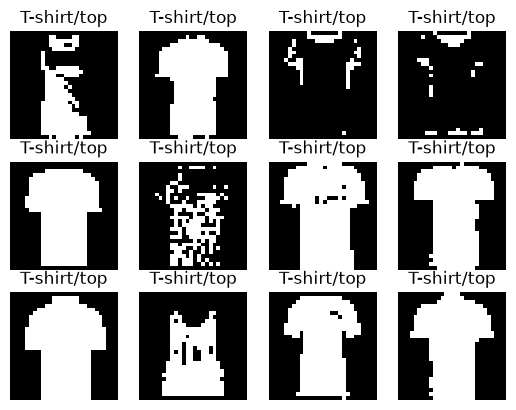

In [47]:
fmnist_train_data = datasets.FashionMNIST(
    root='fmnist/', download=True, train=True, transform=img_transforms
)

labels_used = ["T-shirt/top"]

fmnist_train_data = [
    (image, label)
    for image, label in fmnist_train_data
    if class_names[label] in labels_used
]

fmnist_train_dataloader = DataLoader(
    fmnist_train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

show_fashion_images(
    fmnist_train_data,
    labels_used,
    num_images=12
)

  0%|          | 0/100 [00:00<?, ?it/s]

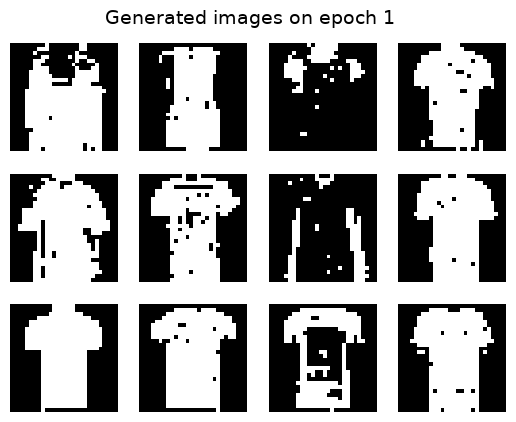

  1%|          | 1/100 [00:00<01:12,  1.36it/s]

Epoch: 1 - duration 0.7346780300140381s- error: 0.11324795490091151


 20%|██        | 20/100 [00:07<00:28,  2.79it/s]

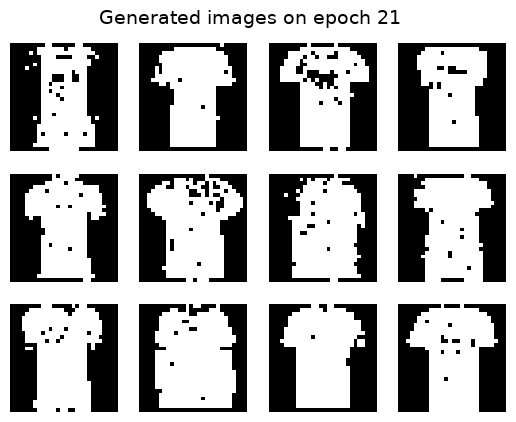

 21%|██        | 21/100 [00:07<00:34,  2.32it/s]

Epoch: 21 - duration 0.601341962814331s- error: 0.10618216881251082


 40%|████      | 40/100 [00:15<00:25,  2.39it/s]

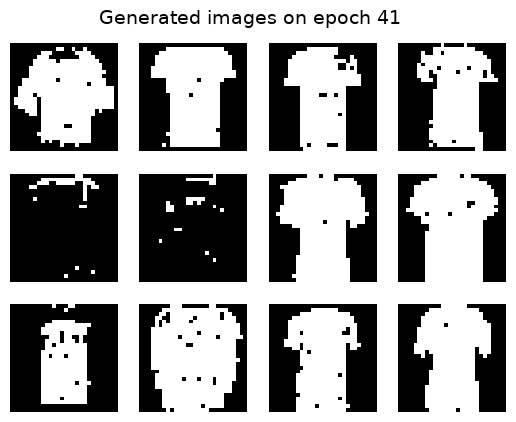

 41%|████      | 41/100 [00:15<00:28,  2.10it/s]

Epoch: 41 - duration 0.6094851493835449s- error: 0.1034978866339364


 60%|██████    | 60/100 [00:23<00:17,  2.29it/s]

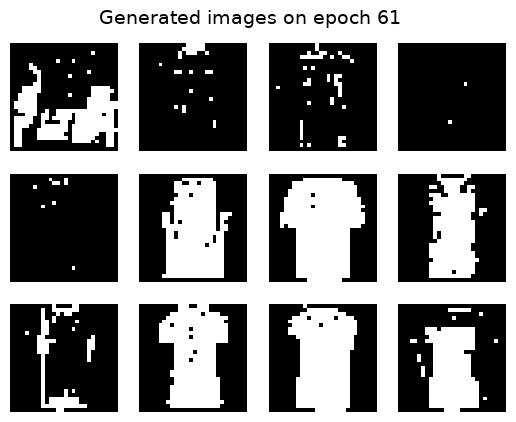

 61%|██████    | 61/100 [00:24<00:19,  2.04it/s]

Epoch: 61 - duration 0.615138053894043s- error: 0.10180485946066836


 80%|████████  | 80/100 [00:31<00:08,  2.41it/s]

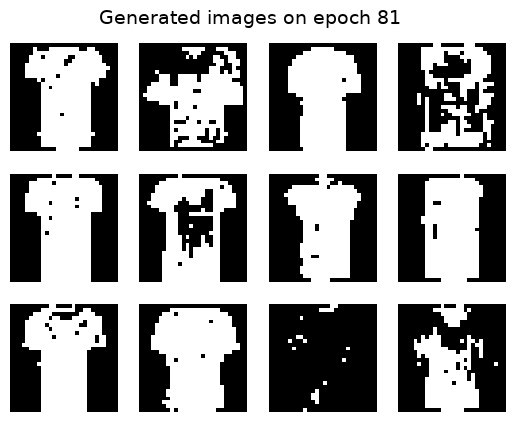

 81%|████████  | 81/100 [00:32<00:09,  2.10it/s]

Epoch: 81 - duration 0.6174089908599854s- error: 0.10067217491884181


100%|██████████| 100/100 [00:39<00:00,  2.53it/s]


In [48]:
trained_model = train_model(
    model=model,
    criterion=criterion,
    n_epochs=int(epochs),
    train_loader=fmnist_train_dataloader,
    optim=optim,
    print_epoch=20
)

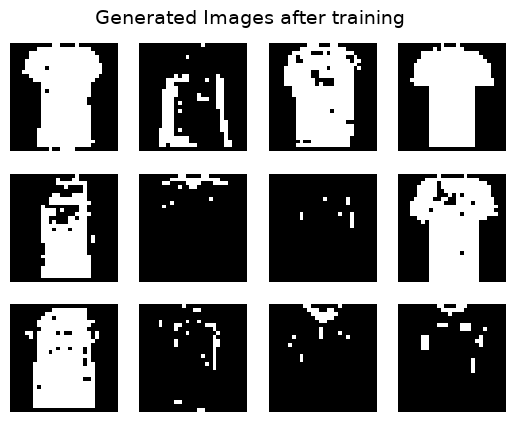

In [49]:
imgs = model.generate_x(12).cpu()
show_images(imgs, "Generated Images after training")

### Entrenar con T-shirt/top y Shirt

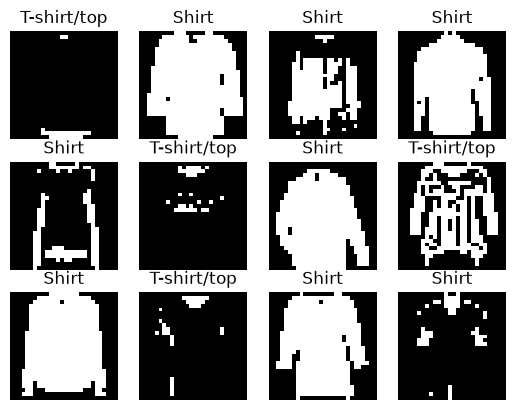

In [50]:
fmnist_train_data = datasets.FashionMNIST(
    root='fmnist/', download=True, train=True, transform=img_transforms
)

labels_used = ["T-shirt/top", "Shirt"]

fmnist_train_data = [
    (image, label)
    for image, label in fmnist_train_data
    if class_names[label] in labels_used
]

fmnist_train_dataloader = DataLoader(
    fmnist_train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

show_fashion_images(
    fmnist_train_data,
    labels_used,
    num_images=12
)

  0%|          | 0/100 [00:00<?, ?it/s]

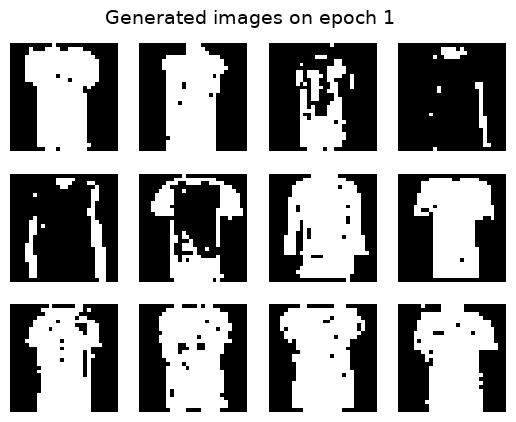

  1%|          | 1/100 [00:00<01:22,  1.20it/s]

Epoch: 1 - duration 0.8367297649383545s- error: 0.14099816491206488


 20%|██        | 20/100 [00:16<01:15,  1.07it/s]

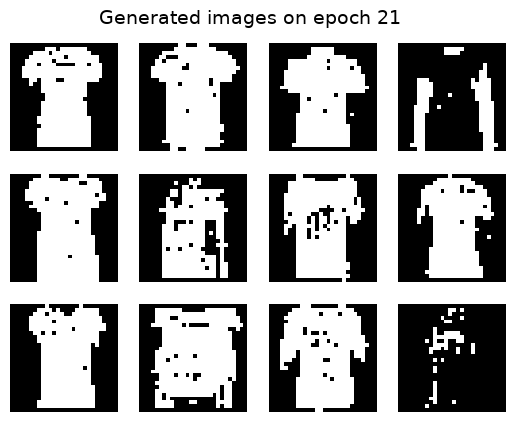

 21%|██        | 21/100 [00:17<01:19,  1.00s/it]

Epoch: 21 - duration 1.148101806640625s- error: 0.12562842891613643


 40%|████      | 40/100 [00:35<00:56,  1.06it/s]

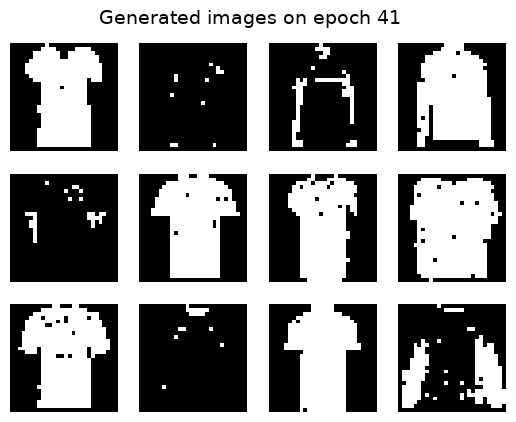

 41%|████      | 41/100 [00:36<00:59,  1.01s/it]

Epoch: 41 - duration 1.1471750736236572s- error: 0.12375714077552159


 60%|██████    | 60/100 [00:53<00:38,  1.05it/s]

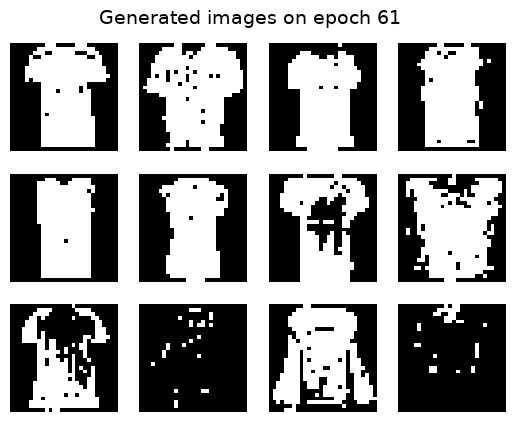

 61%|██████    | 61/100 [00:55<00:39,  1.01s/it]

Epoch: 61 - duration 1.1434552669525146s- error: 0.1231220198671023


 80%|████████  | 80/100 [01:12<00:19,  1.05it/s]

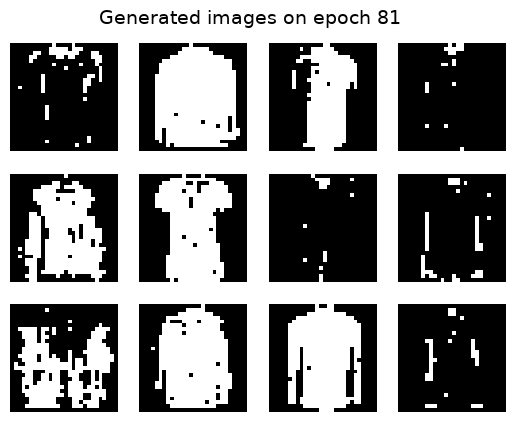

 81%|████████  | 81/100 [01:13<00:18,  1.00it/s]

Epoch: 81 - duration 1.0888378620147705s- error: 0.12277987984816233


100%|██████████| 100/100 [01:30<00:00,  1.10it/s]


In [51]:
trained_model = train_model(
    model=model,
    criterion=criterion,
    n_epochs=int(epochs),
    train_loader=fmnist_train_dataloader,
    optim=optim,
    print_epoch=20
)

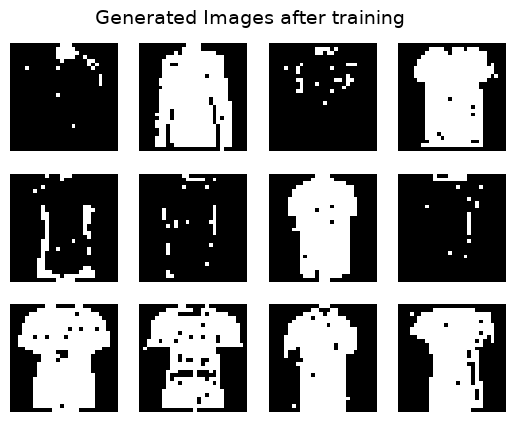

In [53]:
imgs = model.generate_x(12).cpu()
show_images(imgs, "Generated Images after training")

6) Compare y comente sobre los resultados obtenidos.